# From Fixed to Learned Molecular Representations: MLP and Graph Neural Networks on Lipophilicity

*A hands-on comparison of fixed-fingerprint models (MLP) and a learned-representation model (GNN) on the MoleculeNet Lipophilicity dataset, with regularization and a replicated ablation study.*

## Abstract

Notebook 03 showed that on fixed ECFP4 fingerprints, model choice is not the limiting factor: gradient-boosted trees and a multilayer perceptron plateau at the same accuracy because both consume the same frozen representation. This notebook tests the alternative: learning the representation directly from the molecular graph. On the MoleculeNet Lipophilicity dataset (logD, n = 4200), a regularized MLP on fingerprints reaches RMSE ~0.76, close to but not better than the XGBoost baseline (0.705). A naive graph neural network underfits badly (RMSE 1.14), but enriching the atom features and the architecture brings it to RMSE 0.589 +/- 0.024 over five random splits, competitive with published message-passing networks (D-MPNN 0.555, AttentiveFP 0.578). A replicated 2x2 ablation shows that richer features and a more expressive model contribute roughly equally and additively, with no significant interaction once measurement noise is accounted for. The exercise illustrates both the promise of learned representations and the engineering effort required to realise it.

## 1. Introduction

A recurring finding of the preceding notebooks is that a molecule encoded as a 2048-bit Morgan fingerprint carries a fixed, lossy summary of its structure, computed once and never adapted to the task. Notebook 03 made the consequence explicit: on this representation, XGBoost and a multilayer perceptron reach essentially the same accuracy, because the bottleneck is the representation rather than the model that reads it. Any information the fingerprint discards cannot be recovered downstream, however powerful the regressor.

Graph neural networks (GNNs) offer a different paradigm. Instead of a precomputed descriptor, the molecule is handed to the model as its native graph, atoms as nodes and bonds as edges, and the model learns, through message passing, how to summarise that graph into a vector optimised for the target property. The representation is therefore trained end to end rather than frozen in advance.

This notebook builds both kinds of model from scratch on the Lipophilicity dataset and asks a focused question: does learning the representation actually help, and at what cost? The path is deliberately incremental, a fingerprint MLP as a bridge from classical models, a minimal GNN, an improved GNN, and finally a replicated ablation to attribute the gains rigorously.

In [33]:
import sys
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80     # reduit la taille affichee de TOUTES les figures
plt.rcParams["font.size"] = 9       # texte compact mais lisible
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 8
print("Kernel Python:", sys.executable)
!{sys.executable} -m pip install torch

Kernel Python: c:\Users\coure\anaconda3\envs\chemml\python.exe


## 2. Data

All experiments use the MoleculeNet Lipophilicity dataset (octanol/water distribution coefficient, logD at pH 7.4; 4200 compounds curated from ChEMBL), loaded from the DeepChem distribution. A single dataset is used throughout so that differences between models reflect the representation and architecture, not the task. Molecules are held out with a random 80/20 train/validation split; the ablation later repeats this split over several seeds to separate real effects from split-to-split noise.

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

print("torch", torch.__version__)

# --- Featurization (same as notebooks 01-03) ---
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {'LogP': Descriptors.MolLogP(mol), 'MolWt': Descriptors.MolWt(mol),
            'NumHDonors': Descriptors.NumHDonors(mol), 'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'TPSA': Descriptors.TPSA(mol), 'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)}

def compute_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits))

def build_Xy(smiles_series, target_series):
    desc_list = smiles_series.apply(compute_descriptors).tolist()
    mask = [d is not None for d in desc_list]
    smiles_valid = smiles_series[mask].reset_index(drop=True)
    D = pd.DataFrame([d for d in desc_list if d is not None])
    fp = np.array([compute_fingerprint(s) for s in smiles_valid])
    X = np.hstack([fp, D.values]).astype(np.float32)
    y = target_series[np.array(mask)].reset_index(drop=True).values.astype(np.float32)
    return X, y

# --- Lipophilicity ---
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv"
df = pd.read_csv(url)
X, y = build_Xy(df["smiles"], df["exp"])
print("X:", X.shape, "y:", y.shape, "| dtype:", X.dtype)

torch 2.13.0+cpu
X: (4200, 2054) y: (4200,) | dtype: float32


## 3. Methods

### 3.1 Molecular representations

Two representations are compared. The fixed representation reuses the pipeline of the earlier notebooks: a 2048-bit ECFP4 Morgan fingerprint concatenated with six physicochemical descriptors, standardized before training. The learned representation encodes each molecule as a graph, where every atom carries a feature vector and bonds define the connectivity; the graph is passed to a GNN that learns to aggregate it. Two atom featurizations are used: a minimal one (six raw values) and a richer one in which categorical properties (element, degree, hydrogen count, hybridization) are one-hot encoded, since a categorical variable fed as a single integer imposes a meaningless ordering on the network.

### 3.2 Models

Three models are trained. A multilayer perceptron (MLP) on the fixed features serves as the neural baseline. A graph neural network processes the molecular graph through successive message-passing layers followed by a global pooling step and a linear head. All neural models are trained by gradient descent (Adam optimiser) minimising the mean squared error, with early stopping on the validation loss; the MLP additionally uses dropout and weight decay to control overfitting.

### 3.3 Evaluation

Models are compared by validation RMSE. For the final ablation, each configuration is retrained over five random splits and reported as mean +/- standard deviation, so that the size of an effect can be judged against its noise.

In [3]:
class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256),  # couche cachee 1 : 2054 -> 256 neurones
            nn.ReLU(),                   # activation (non-linearite)
            nn.Linear(256, 64),          # couche cachee 2 : 256 -> 64
            nn.ReLU(),
            nn.Linear(64, 1),            # sortie : 64 -> 1 (valeur predite)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)    # (batch, 1) -> (batch,)

model = MLP(X.shape[1])
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=2054, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split train / validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Standardisation des features (ajustee sur le train uniquement)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)

# 3. Conversion en tenseurs torch
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_val_t   = torch.tensor(X_val)
y_val_t   = torch.tensor(y_val)

print("train:", X_train_t.shape, "| val:", X_val_t.shape)

train: torch.Size([3360, 2054]) | val: torch.Size([840, 2054])


## 4. Results

### 4.1 MLP on fixed fingerprints

Trained without regularization, the MLP overfits sharply: the training MSE collapses toward zero while the validation MSE plateaus near 0.6 (RMSE ~0.77), the training and validation curves separating after roughly 25 epochs. Adding dropout, weight decay and early stopping closes most of the gap and yields a validation RMSE of about 0.76. This is close to, but does not beat, the XGBoost baseline of 0.705 from notebook 03, and it required substantially more machinery to reach. On fixed tabular features, gradient-boosted trees remain a strong, low-effort baseline, and adding neural capacity does not move the ceiling.

In [5]:
model = MLP(X_train_t.shape[1])
loss_fn = nn.MSELoss()                                     # l'erreur (l'altitude)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # la regle du pas (lr = learning rate)

n_epochs = 200
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    # --- entrainement ---
    model.train()
    optimizer.zero_grad()            # remettre les pentes a zero
    pred = model(X_train_t)          # passe avant : prediction
    loss = loss_fn(pred, y_train_t)  # erreur du moment
    loss.backward()                  # retropropagation : calcule la pente pour chaque poids
    optimizer.step()                 # un pas vers le bas : met a jour les poids

    # --- validation (on regarde, on n'apprend pas) ---
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val_t), y_val_t)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    if epoch % 20 == 0:
        print("epoch", epoch, "| train MSE:", round(loss.item(), 3), "| val MSE:", round(val_loss.item(), 3))

epoch 0 | train MSE: 5.892 | val MSE: 4.947
epoch 20 | train MSE: 0.272 | val MSE: 0.777
epoch 40 | train MSE: 0.076 | val MSE: 0.647
epoch 60 | train MSE: 0.022 | val MSE: 0.62
epoch 80 | train MSE: 0.008 | val MSE: 0.606
epoch 100 | train MSE: 0.004 | val MSE: 0.599
epoch 120 | train MSE: 0.003 | val MSE: 0.595
epoch 140 | train MSE: 0.002 | val MSE: 0.593
epoch 160 | train MSE: 0.002 | val MSE: 0.592
epoch 180 | train MSE: 0.001 | val MSE: 0.592


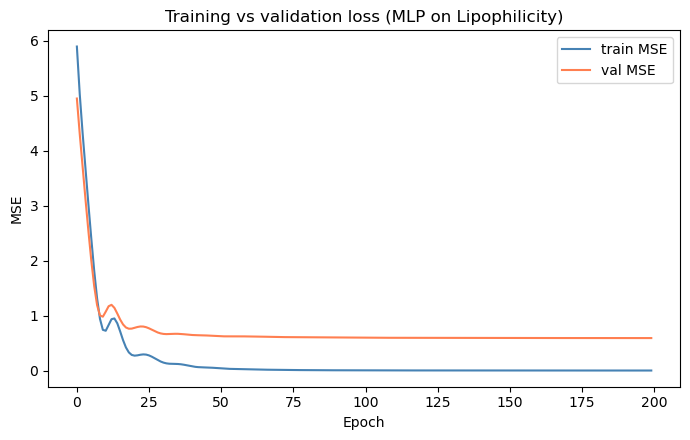

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))
plt.plot(train_losses, label="train MSE", color="steelblue")
plt.plot(val_losses, label="val MSE", color="coral")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs validation loss (MLP on Lipophilicity)")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
class MLP(nn.Module):
    def __init__(self, n_features, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.ReLU(),
            nn.Dropout(p_drop),          # eteint 30% des neurones pendant l'entrainement
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

In [8]:
import copy

model = MLP(X_train_t.shape[1])
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # L2

n_epochs, patience = 500, 20
best_val, best_state, wait = float("inf"), None, 0
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    loss = loss_fn(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val_t), y_val_t).item()
    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val:                       # amelioration : on sauvegarde
        best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
    else:                                         # pas d'amelioration
        wait += 1
        if wait >= patience:
            print("Early stopping at epoch", epoch)
            break

model.load_state_dict(best_state)                 # on restaure le meilleur modele
print("Best val MSE:", round(best_val, 4), "| RMSE:", round(best_val ** 0.5, 4))

Early stopping at epoch 163
Best val MSE: 0.5915 | RMSE: 0.7691


In [9]:
import torch
from torch_geometric.data import Data
from rdkit import Chem

def atom_features(atom):
    return [
        atom.GetAtomicNum(),       # numero atomique
        atom.GetDegree(),          # nombre de voisins
        atom.GetFormalCharge(),    # charge
        atom.GetTotalNumHs(),      # hydrogenes
        int(atom.GetIsAromatic()), # aromatique ?
        int(atom.IsInRing()),      # dans un cycle ?
    ]

def mol_to_graph(smiles, y_value):
    mol = Chem.MolFromSmiles(smiles)
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]                      # liaison non orientee -> deux sens
    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index, y=torch.tensor([y_value], dtype=torch.float))

# test sur une molecule
g = mol_to_graph("CCO", 1.0)
print(g)
print("node features (x):\n", g.x)
print("edge_index:\n", g.edge_index)

Data(x=[3, 6], edge_index=[2, 4], y=[1])
node features (x):
 tensor([[6., 1., 0., 3., 0., 0.],
        [6., 2., 0., 2., 0., 0.],
        [8., 1., 0., 1., 0., 0.]])
edge_index:
 tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])


In [10]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# Tous les graphes
graphs = []
for smi, val in zip(df["smiles"], df["exp"]):
    if Chem.MolFromSmiles(smi) is not None:
        graphs.append(mol_to_graph(smi, float(val)))
print("total graphs:", len(graphs))

# Split train / val
train_graphs, val_graphs = train_test_split(graphs, test_size=0.2, random_state=42)

# Chargeurs : des lots (batches) de graphes
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=64)
print("train:", len(train_graphs), "| val:", len(val_graphs))

total graphs: 4200
train: 3360 | val: 840


### 4.2 A minimal graph neural network

A minimal GNN (two GCN layers, six raw atom features, mean pooling) reaches only RMSE 1.14, worse than both the MLP and XGBoost. The diagnosis is the opposite of the MLP's: training and validation errors are close but both high, the signature of underfitting rather than overfitting. The model is too impoverished, crude integer features on an unnormalised scale and a weak aggregation, to extract the signal. A learned representation is a potential, not an automatic advantage.

In [11]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GNN(nn.Module):
    def __init__(self, n_node_features, hidden=64):
        super().__init__()
        self.conv1 = GCNConv(n_node_features, hidden)   # message passing, round 1
        self.conv2 = GCNConv(hidden, hidden)            # message passing, round 2
        self.head  = nn.Linear(hidden, 1)               # prediction finale

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))   # chaque atome agrege ses voisins -> se met a jour
        x = F.relu(self.conv2(x, edge_index))   # encore : voisinage a 2 liaisons
        x = global_mean_pool(x, batch)          # readout : moyenne des atomes -> 1 vecteur / molecule
        return self.head(x).squeeze(1)

model = GNN(n_node_features=6)
print(model)

GNN(
  (conv1): GCNConv(6, 64)
  (conv2): GCNConv(64, 64)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


In [12]:
import copy

model = GNN(n_node_features=6)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    for batch in loader:
        with torch.set_grad_enabled(train):
            pred = model(batch)
            loss = loss_fn(pred, batch.y)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total += loss.item() * batch.num_graphs
        n += batch.num_graphs
    return total / n

n_epochs, patience = 100, 15
best_val, best_state, wait = float("inf"), None, 0
for epoch in range(n_epochs):
    train_mse = run_epoch(train_loader, train=True)
    val_mse   = run_epoch(val_loader, train=False)
    if val_mse < best_val:
        best_val, best_state, wait = val_mse, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping at epoch", epoch); break
    if epoch % 5 == 0:
        print("epoch", epoch, "| train MSE:", round(train_mse, 3), "| val MSE:", round(val_mse, 3))

model.load_state_dict(best_state)
print("Best val MSE:", round(best_val, 4), "| RMSE:", round(best_val ** 0.5, 4))

epoch 0 | train MSE: 1.894 | val MSE: 1.506
epoch 5 | train MSE: 1.423 | val MSE: 1.469
epoch 10 | train MSE: 1.378 | val MSE: 1.385
epoch 15 | train MSE: 1.362 | val MSE: 1.382
epoch 20 | train MSE: 1.371 | val MSE: 1.391
epoch 25 | train MSE: 1.358 | val MSE: 1.394
epoch 30 | train MSE: 1.36 | val MSE: 1.367
epoch 35 | train MSE: 1.354 | val MSE: 1.365
epoch 40 | train MSE: 1.356 | val MSE: 1.352
epoch 45 | train MSE: 1.356 | val MSE: 1.343
epoch 50 | train MSE: 1.337 | val MSE: 1.341
epoch 55 | train MSE: 1.339 | val MSE: 1.376
epoch 60 | train MSE: 1.334 | val MSE: 1.38
epoch 65 | train MSE: 1.328 | val MSE: 1.332
epoch 70 | train MSE: 1.327 | val MSE: 1.326
epoch 75 | train MSE: 1.312 | val MSE: 1.326
epoch 80 | train MSE: 1.312 | val MSE: 1.326
epoch 85 | train MSE: 1.311 | val MSE: 1.316
epoch 90 | train MSE: 1.294 | val MSE: 1.332
epoch 95 | train MSE: 1.288 | val MSE: 1.298
Best val MSE: 1.2962 | RMSE: 1.1385


### 4.3 Improving the graph neural network

Enriching the atom features (one-hot element, degree, hydrogen count and hybridization) and the architecture (GraphConv layers, greater depth and width, combined mean and sum pooling) reduces the validation RMSE to 0.573 on a single split. This now surpasses the MLP (0.76) and XGBoost (0.705) and enters the range of published graph networks. The learned representation, once given enough information and capacity, delivers on its promise.

In [13]:
from torch_geometric.nn import GraphConv, global_mean_pool, global_add_pool

ELEMENTS = [6, 7, 8, 9, 15, 16, 17, 35, 53]          # C N O F P S Cl Br I
HYBRID = [Chem.rdchem.HybridizationType.SP,
          Chem.rdchem.HybridizationType.SP2,
          Chem.rdchem.HybridizationType.SP3]

def onehot(v, choices):
    return [int(v == c) for c in choices] + [int(v not in choices)]

def atom_features(atom):
    return (
        onehot(atom.GetAtomicNum(), ELEMENTS)          # element
        + onehot(atom.GetDegree(), [0, 1, 2, 3, 4])    # nb de voisins
        + onehot(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])# nb d'hydrogenes
        + onehot(atom.GetHybridization(), HYBRID)      # hybridation
        + [atom.GetFormalCharge(),
           int(atom.GetIsAromatic()),
           int(atom.IsInRing())]
    )

N_FEAT = len(atom_features(Chem.MolFromSmiles("CCO").GetAtomWithIdx(0)))
print("node feature dim:", N_FEAT)

# reconstruire les graphes avec les nouvelles features
graphs = [mol_to_graph(smi, float(val))
          for smi, val in zip(df["smiles"], df["exp"])
          if Chem.MolFromSmiles(smi) is not None]
train_graphs, val_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=64)
print("graphs rebuilt:", len(graphs))

node feature dim: 29
graphs rebuilt: 4200


In [14]:
class GNN2(nn.Module):
    def __init__(self, n_node_features, hidden=128):
        super().__init__()
        self.conv1 = GraphConv(n_node_features, hidden)
        self.conv2 = GraphConv(hidden, hidden)
        self.conv3 = GraphConv(hidden, hidden)
        self.head = nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, 1),
        )
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = torch.cat([global_mean_pool(x, batch), global_add_pool(x, batch)], dim=1)
        return self.head(x).squeeze(1)

model = GNN2(N_FEAT)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

n_epochs, patience = 150, 20
best_val, best_state, wait = float("inf"), None, 0
for epoch in range(n_epochs):
    train_mse = run_epoch(train_loader, train=True)
    val_mse   = run_epoch(val_loader, train=False)
    if val_mse < best_val:
        best_val, best_state, wait = val_mse, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping at epoch", epoch); break
    if epoch % 10 == 0:
        print("epoch", epoch, "| train MSE:", round(train_mse, 3), "| val MSE:", round(val_mse, 3))

model.load_state_dict(best_state)
print("Best val MSE:", round(best_val, 4), "| RMSE:", round(best_val ** 0.5, 4))

epoch 0 | train MSE: 2.086 | val MSE: 1.353
epoch 10 | train MSE: 0.544 | val MSE: 0.625
epoch 20 | train MSE: 0.404 | val MSE: 0.456
epoch 30 | train MSE: 0.345 | val MSE: 0.442
epoch 40 | train MSE: 0.266 | val MSE: 0.395
epoch 50 | train MSE: 0.242 | val MSE: 0.405
epoch 60 | train MSE: 0.227 | val MSE: 0.391
epoch 70 | train MSE: 0.184 | val MSE: 0.355
epoch 80 | train MSE: 0.16 | val MSE: 0.343
epoch 90 | train MSE: 0.169 | val MSE: 0.341
Early stopping at epoch 99
Best val MSE: 0.3283 | RMSE: 0.573


In [ ]:
class GNN2(nn.Module):
    def __init__(self, n_node_features, hidden=128):
        super().__init__()
        self.conv1 = GraphConv(n_node_features, hidden)
        self.conv2 = GraphConv(hidden, hidden)
        self.conv3 = GraphConv(hidden, hidden)
        self.head = nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, 1),
        )
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = torch.cat([global_mean_pool(x, batch), global_add_pool(x, batch)], dim=1)
        return self.head(x).squeeze(1)

model = GNN2(N_FEAT)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

n_epochs, patience = 150, 20
best_val, best_state, wait = float("inf"), None, 0
for epoch in range(n_epochs):
    train_mse = run_epoch(train_loader, train=True)
    val_mse   = run_epoch(val_loader, train=False)
    if val_mse < best_val:
        best_val, best_state, wait = val_mse, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping at epoch", epoch); break
    if epoch % 10 == 0:
        print("epoch", epoch, "| train MSE:", round(train_mse, 3), "| val MSE:", round(val_mse, 3))

model.load_state_dict(best_state)
print("Best val MSE:", round(best_val, 4), "| RMSE:", round(best_val ** 0.5, 4))

epoch 0 | train MSE: 2.925 | val MSE: 1.484
epoch 10 | train MSE: 1.117 | val MSE: 1.118
epoch 20 | train MSE: 0.983 | val MSE: 1.002
epoch 30 | train MSE: 0.89 | val MSE: 1.019
epoch 40 | train MSE: 0.788 | val MSE: 0.83
epoch 50 | train MSE: 0.738 | val MSE: 0.8
epoch 60 | train MSE: 0.709 | val MSE: 0.777
epoch 70 | train MSE: 0.712 | val MSE: 0.746
epoch 80 | train MSE: 0.669 | val MSE: 0.731
epoch 90 | train MSE: 0.651 | val MSE: 0.724
epoch 100 | train MSE: 0.664 | val MSE: 0.709
epoch 110 | train MSE: 0.63 | val MSE: 0.704
epoch 120 | train MSE: 0.635 | val MSE: 0.718
epoch 130 | train MSE: 0.618 | val MSE: 0.695
epoch 140 | train MSE: 0.6 | val MSE: 0.681
Best val MSE: 0.6741 | RMSE: 0.8211


In [16]:
# --- Experiment B: OLD features (6, brutes) + NEW model (GNN2) ---
def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
    ]

N_FEAT = len(atom_features(Chem.MolFromSmiles("CCO").GetAtomWithIdx(0)))
print("node feature dim:", N_FEAT)   # doit afficher 6

# reconstruire graphes + loaders avec les ANCIENNES features
graphs = [mol_to_graph(smi, float(val))
          for smi, val in zip(df["smiles"], df["exp"])
          if Chem.MolFromSmiles(smi) is not None]
train_graphs, val_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=64)
print("graphs rebuilt with OLD features:", len(graphs))

node feature dim: 6
graphs rebuilt with OLD features: 4200


In [17]:
import copy

model = GNN2(n_node_features=6)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    for batch in loader:
        with torch.set_grad_enabled(train):
            pred = model(batch)
            loss = loss_fn(pred, batch.y)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total += loss.item() * batch.num_graphs
        n += batch.num_graphs
    return total / n

n_epochs, patience = 100, 15
best_val, best_state, wait = float("inf"), None, 0
for epoch in range(n_epochs):
    train_mse = run_epoch(train_loader, train=True)
    val_mse   = run_epoch(val_loader, train=False)
    if val_mse < best_val:
        best_val, best_state, wait = val_mse, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping at epoch", epoch); break
    if epoch % 5 == 0:
        print("epoch", epoch, "| train MSE:", round(train_mse, 3), "| val MSE:", round(val_mse, 3))

model.load_state_dict(best_state)
print("Best val MSE:", round(best_val, 4), "| RMSE:", round(best_val ** 0.5, 4))

epoch 0 | train MSE: 74.25 | val MSE: 1.574
epoch 5 | train MSE: 1.417 | val MSE: 1.345
epoch 10 | train MSE: 1.496 | val MSE: 1.362
epoch 15 | train MSE: 1.381 | val MSE: 1.344
epoch 20 | train MSE: 1.412 | val MSE: 1.298
epoch 25 | train MSE: 1.309 | val MSE: 1.365
epoch 30 | train MSE: 1.323 | val MSE: 1.261
epoch 35 | train MSE: 1.25 | val MSE: 1.252
epoch 40 | train MSE: 1.177 | val MSE: 1.111
epoch 45 | train MSE: 1.115 | val MSE: 1.043
epoch 50 | train MSE: 1.148 | val MSE: 1.046
epoch 55 | train MSE: 1.165 | val MSE: 1.011
epoch 60 | train MSE: 1.103 | val MSE: 1.018
epoch 65 | train MSE: 0.982 | val MSE: 0.984
epoch 70 | train MSE: 1.002 | val MSE: 0.938
epoch 75 | train MSE: 0.967 | val MSE: 0.93
epoch 80 | train MSE: 0.924 | val MSE: 0.87
epoch 85 | train MSE: 0.857 | val MSE: 0.844
epoch 90 | train MSE: 0.82 | val MSE: 0.826
epoch 95 | train MSE: 0.804 | val MSE: 0.81
Best val MSE: 0.8104 | RMSE: 0.9002


In [18]:
def atom_features_rich(atom):
    return (onehot(atom.GetAtomicNum(), ELEMENTS)
            + onehot(atom.GetDegree(), [0, 1, 2, 3, 4])
            + onehot(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])
            + onehot(atom.GetHybridization(), HYBRID)
            + [atom.GetFormalCharge(), int(atom.GetIsAromatic()), int(atom.IsInRing())])

def atom_features_simple(atom):
    return [atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
            atom.GetTotalNumHs(), int(atom.GetIsAromatic()), int(atom.IsInRing())]

def build_graphs(featurizer):
    global atom_features
    atom_features = featurizer          # mol_to_graph lit la globale atom_features
    return [mol_to_graph(smi, float(val))
            for smi, val in zip(df["smiles"], df["exp"])
            if Chem.MolFromSmiles(smi) is not None]

old_graphs = build_graphs(atom_features_simple)
new_graphs = build_graphs(atom_features_rich)
print("old:", old_graphs[0].x.shape[1], "features | new:", new_graphs[0].x.shape[1], "features")

old: 6 features | new: 29 features


### 4.4 Ablation study

To attribute the improvement, a 2x2 ablation crosses the two featurizations with the two architectures, each retrained over five random splits.

| Model | Old features (6) | Rich features (29) |
|---|---|---|
| GCN (minimal) | 1.156 +/- 0.035 | 0.885 +/- 0.056 |
| GraphConv (improved) | 0.876 +/- 0.044 | 0.589 +/- 0.024 |

The standard deviations (0.02 to 0.06) are far smaller than the gaps between cells (0.27 to 0.29), so every effect is real rather than noise. Richer features and the stronger architecture each lower the RMSE by about 0.28, roughly equally, and their combined effect (1.156 to 0.589) is close to the sum of the individual effects, indicating no meaningful interaction. An apparent interaction seen on a single split did not survive replication, a reminder that effects must be weighed against split-to-split variability before being interpreted.

In [19]:
def train_config(graphs, model_class, seed, n_epochs=100, patience=15):
    tr, va = train_test_split(graphs, test_size=0.2, random_state=seed)
    tl = DataLoader(tr, batch_size=64, shuffle=True)
    vl = DataLoader(va, batch_size=64)
    n_feat = graphs[0].x.shape[1]
    torch.manual_seed(seed)                       # init des poids reproductible
    m = model_class(n_feat)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)

    def epoch_pass(loader, train):
        m.train() if train else m.eval()
        tot = n = 0.0
        for b in loader:
            with torch.set_grad_enabled(train):
                loss = loss_fn(m(b), b.y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * b.num_graphs; n += b.num_graphs
        return tot / n

    best, wait = float("inf"), 0
    for _ in range(n_epochs):
        epoch_pass(tl, True)
        v = epoch_pass(vl, False)
        if v < best: best, wait = v, 0
        else:
            wait += 1
            if wait >= patience: break
    return best ** 0.5                             # RMSE

configs = {
    "old feat + GCN":       (old_graphs, GNN),
    "new feat + GCN":       (new_graphs, GNN),
    "old feat + GraphConv": (old_graphs, GNN2),
    "new feat + GraphConv": (new_graphs, GNN2),
}
for name, (g, mc) in configs.items():
    rmses = [train_config(g, mc, s) for s in range(5)]
    print(name.ljust(22), "RMSE:", round(np.mean(rmses), 3), "+/-", round(np.std(rmses), 3))

old feat + GCN         RMSE: 1.156 +/- 0.035
new feat + GCN         RMSE: 0.885 +/- 0.056
old feat + GraphConv   RMSE: 0.876 +/- 0.044
new feat + GraphConv   RMSE: 0.589 +/- 0.024


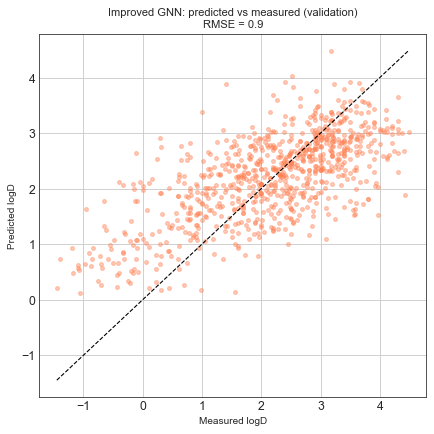

In [34]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for b in val_loader:
        y_pred += model(b).tolist()
        y_true += b.y.tolist()
y_true, y_pred = np.array(y_true), np.array(y_pred)
rmse = np.sqrt(((y_true - y_pred) ** 2).mean())

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_true, y_pred, s=12, alpha=0.4, color="coral")
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Measured logD"); plt.ylabel("Predicted logD")
plt.title("Improved GNN: predicted vs measured (validation)\nRMSE = " + str(round(rmse, 3)))
plt.tight_layout(); plt.show()

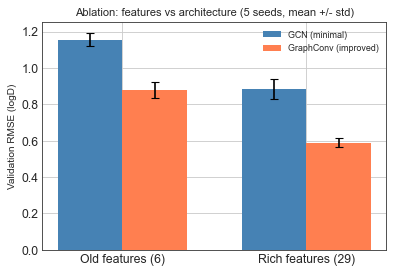

In [35]:
import numpy as np
import matplotlib.pyplot as plt

groups = ["Old features (6)", "Rich features (29)"]
gcn_mean, gcn_std = [1.156, 0.885], [0.035, 0.056]
gcv_mean, gcv_std = [0.876, 0.589], [0.044, 0.024]

x = np.arange(len(groups)); w = 0.35
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(x - w/2, gcn_mean, w, yerr=gcn_std, capsize=4, color="steelblue", label="GCN (minimal)")
ax.bar(x + w/2, gcv_mean, w, yerr=gcv_std, capsize=4, color="coral", label="GraphConv (improved)")
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("Validation RMSE (logD)")
ax.set_title("Ablation: features vs architecture (5 seeds, mean +/- std)")
ax.legend()
plt.tight_layout(); plt.show()

## 5. Discussion

Taken together, the experiments trace a clear line from fixed to learned representations. On fixed fingerprints, neural capacity buys little: the regularized MLP only matches gradient-boosted trees, confirming that the frozen representation, not the model, sets the ceiling. Learning the representation removes that ceiling, but only when the graph model is given informative atom features and sufficient capacity; a naive GNN underfits and performs worse than the classical baseline. The best learned model (RMSE 0.589 +/- 0.024) is competitive with published message-passing networks, although a rigorous comparison would require matching their exact splitting protocol rather than the random split used here.

The study also illustrates two transferable diagnostic habits. Comparing training and validation error identifies which failure is at play: a large gap indicates overfitting and calls for regularization, whereas uniformly high error indicates underfitting and calls for a richer model. And replicating an experiment across seeds distinguishes genuine effects from noise: the ablation's main effects (features and architecture, each about 0.28 RMSE) are robust, while a suspected interaction proved to be an artifact of a single split.

Several limitations temper the conclusions. A single property and dataset were used, so the ranking may not transfer to other endpoints. Evaluation relied on a random split rather than a scaffold split, so the numbers describe in-distribution performance rather than generalisation to novel chemotypes. Finally, the models were only lightly tuned on CPU; the published networks that reach RMSE below 0.58 use richer featurization, attention mechanisms and considerably more optimisation.

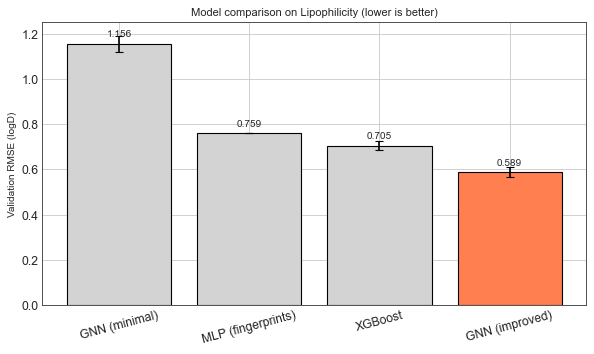

In [36]:
models = ["GNN (minimal)", "MLP (fingerprints)", "XGBoost", "GNN (improved)"]
rmse   = [1.156, 0.759, 0.705, 0.589]
err    = [0.035, 0.0,   0.021, 0.024]           # std connu pour KFold/multi-seed ; 0 = split unique
colors = ["lightgray", "lightgray", "lightgray", "coral"]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(models, rmse, yerr=err, capsize=4, color=colors, edgecolor="black")
ax.set_ylabel("Validation RMSE (logD)")
ax.set_title("Model comparison on Lipophilicity (lower is better)")
for i, v in enumerate(rmse):
    ax.text(i, v + 0.03, str(v), ha="center", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 6. Conclusion

Building an MLP and a graph neural network from first principles on the Lipophilicity dataset makes concrete the central lesson of the series: the molecular representation, more than the choice of model, governs predictive performance. A fixed fingerprint caps both trees and neural networks at comparable accuracy, whereas a learned graph representation, once adequately engineered, becomes competitive with published message-passing baselines (0.589 +/- 0.024 RMSE). A replicated ablation attributes this gain, in roughly equal and additive parts, to richer atom features and a more expressive architecture. The result is not that deep learning is inherently superior, but that its advantage is conditional on engineering effort, and that honest evaluation, diagnosing overfitting versus underfitting and weighing effects against noise, matters as much as the models themselves.

## Appendix: key concepts from this notebook

**Neuron and network.** A neuron computes a weighted sum of its inputs plus a bias; without an activation function it is exactly a linear model. Stacking neurons in layers with non-linear activations (ReLU) lets a network approximate arbitrary functions.

**Training.** Weights start random and are adjusted by gradient descent: the loss (mean squared error) is the quantity minimised, backpropagation computes its gradient with respect to every weight, and the optimiser steps downhill; the learning rate is the step size. One pass over the data is an epoch.

**Overfitting vs underfitting.** Low training error with high validation error means the model memorises (overfitting), addressed by dropout, weight decay and early stopping. Uniformly high error means the model cannot capture the signal (underfitting), addressed by richer features or more capacity.

**Message passing (GNN).** Each atom repeatedly aggregates its neighbours' vectors along bonds and updates itself; after k rounds it encodes a k-hop neighbourhood (the analogue of Morgan radius k), but the aggregation is learned rather than a fixed hash. A readout pools all atom vectors into a single molecule vector.

**Ablation and replication.** To attribute an improvement to a specific change, vary one factor at a time (ablation), and repeat over several random splits to check that an observed effect exceeds the noise before interpreting it.